In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import glob
import numpy as np
from sklearn.cluster import KMeans
#from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import random

In [15]:
input_dir = Path("/home/yuqiong.liu/work/data/ngen_reg/inputs")
domain1 = "conus"

In [16]:
# read catchment-gage crosswalk
cwt_file = Path(input_dir, 'cwt_ngen_donor', 'calib_gage_divide_' + domain1 + '.parquet')
if not cwt_file.exists():
    print(f"Crosswalk file {cwt_file} does not exist. Please run the script to create it.")
else:
    df_cats = pd.read_parquet(cwt_file)

In [4]:
def sample_locations(locations, n_samples):
    """
    Selects a uniform sample of locations using KMeans clustering.

    :param locations: DataFrame with 'latitude' and 'longitude' columns.
    :param n_samples: Number of locations to sample.
    :return: DataFrame with sampled locations.
    """
    if len(locations) <= n_samples:
        return locations  

    # Convert to numpy array for clustering
    coords = locations[['latitude', 'longitude']].to_numpy()

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_samples, random_state=42, n_init=10)
    kmeans.fit(coords)
    
    # Find the closest point to each cluster center
    sampled_indices = []
    for center in kmeans.cluster_centers_:
        closest_idx = np.argmin(np.linalg.norm(coords - center, axis=1))
        sampled_indices.append(closest_idx)

    return locations.iloc[sampled_indices]

In [18]:
# create sample locations (assuming these locations are calibrated for multiple formulations)
n_sample = 1000
gages = pd.read_csv("/home/yuqiong.liu/work/data/gages_nwm4_calib_all.csv")
gages = gages[gages['agency'].str.lower() == 'usgs']
df_gages = df_cats.merge(gages[['gage_id','latitude','longitude']], how='left')[['gage_id','latitude','longitude','vpuid']]
df_gages = df_gages.drop_duplicates()
df_gages = df_gages[~df_gages['latitude'].isna() | ~df_gages['longitude'].isna()]
print(f'Sample {n_sample} locations from a total of {len(df_gages)} in the {domain} domain')
sampled_gages = sample_locations(df_gages, n_sample).reset_index().drop(columns=['index'])
#display(sampled_gages)

Sample 1000 locations from a total of 1479 in the CONUS domain


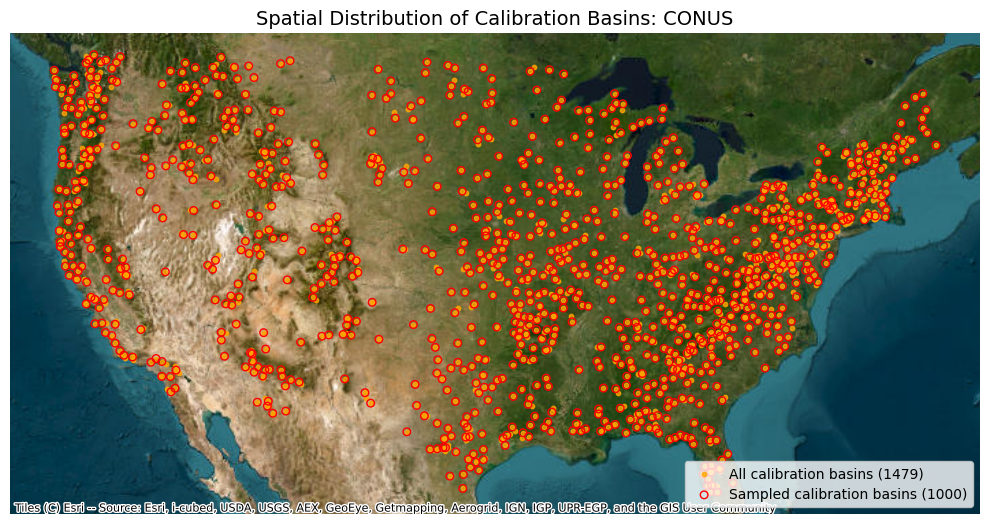

In [19]:
#Plots all calibration basins on a map with sampled basins highlighted
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

def plot_map_static(locations, sampled_locations, domain, crs='EPSG:4326'):
    """
    Plots all locations and sampled locations on a basemap using GeoPandas + Contextily.
    
    :param locations: DataFrame with 'latitude' and 'longitude' columns
    :param sampled_locations: same structure
    :param domain: name of the domain for the plot title
    :param crs: coordinate reference system (default is WGS84)
    """
    # Convert DataFrames to GeoDataFrames
    gdf_all = gpd.GeoDataFrame(locations.copy(),
                               geometry=gpd.points_from_xy(locations.longitude, locations.latitude),
                               crs=crs)

    gdf_sampled = gpd.GeoDataFrame(sampled_locations.copy(),
                                   geometry=gpd.points_from_xy(sampled_locations.longitude, sampled_locations.latitude),
                                   crs=crs)

    # Project to Web Mercator for contextily
    gdf_all_web = gdf_all.to_crs(epsg=3857)
    gdf_sampled_web = gdf_sampled.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf_all_web.plot(ax=ax, color='orange', markersize=10, alpha=0.8, 
                     label=f'All calibration basins ({len(gdf_all)})')
    gdf_sampled_web.plot(ax=ax, facecolor='none', edgecolor='red', markersize=30, 
                         label=f'Sampled calibration basins ({len(gdf_sampled)})')


    # Add basemap
    # Uncomment one of the following lines to use a different basemap, but Stamen does not work with the latest contextily
    #ctx.add_basemap(ax, source=ctx.providers.Stamen.Terrain)
    #ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)

    #ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite)
    #ctx.add_basemap(ax, source=ctx.providers.Stamen.Watercolor)
    #ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

    ax.set_axis_off()
    ax.set_title(f"Spatial Distribution of Calibration Basins: {domain}", fontsize=14)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# plot the map with sampled locations
plot_map_static(df_gages, sampled_gages, domain)

In [ ]:
# Old method based on Basemap. Plots all calibration basins on a map with sampled basins highlighted
def plot_map(locations, sampled_locations):
    """
    :param locations: DataFrame with 'latitude' and 'longitude' columns (all locations).
    :param sampled_locations: DataFrame with 'latitude' and 'longitude' columns (sampled locations).
    """
    plt.figure(figsize=(10, 8))

    # Set up Basemap (adjust projection as needed)
    m = Basemap(projection='merc', 
                llcrnrlat=min(locations['latitude']) - 2, 
                urcrnrlat=max(locations['latitude']) + 2,
                llcrnrlon=min(locations['longitude']) - 2, 
                urcrnrlon=max(locations['longitude']) + 2,
                resolution='i')

    m.drawcoastlines()
    m.drawcountries()
    m.drawmapboundary(fill_color='lightblue')
    m.fillcontinents(color='lightgray', lake_color='lightblue')

    # Convert lat/lon to map coordinates
    x_all, y_all = m(locations['longitude'].values, locations['latitude'].values)
    x_sampled, y_sampled = m(sampled_locations['longitude'].values, sampled_locations['latitude'].values)

    # Plot all locations
    m.scatter(x_all, y_all, s=10, alpha=0.3, color='blue', label='All calibration basins')
    m.scatter(x_sampled, y_sampled, s=30, facecolor='none', color='red', label='Sampled calibration basins')

    plt.legend(loc='lower right')
    plt.title("Spatial Distribution of Calibration Basins")
    plt.show()

plot_map(df_gages, sampled_gages)

In [10]:
# read calib/valid stats from NWMv3 calibration
stats = ['bias','rmse', 'cor', 'nse', 'nselog', 'nseWt', 'kge', 'msof',
       'hyperResMultiObj', 'nnsesq', 'eventmultiobj', 'lbem', 'lbemprime',
       'corr1', 'pod', 'far', 'csi', 'nnse', 'peak_bias', 'peak_tm_err_hr',
       'event_volume_bias']
stats_dict = {}
for eval_period in ['calib','valid','full']:    
       statsAll = pd.read_csv(Path(outdir, 'stats_calib_valid_nwmv3.csv'))
       statsAll['simulation'] = 'calibrated'
       statsAll = statsAll[(statsAll['simulation']=='calibrated') & (statsAll['evalPeriod']==eval_period) & (statsAll['jobID']<100)]
       statsAll = statsAll[['evalPeriod'] + stats]
       statsAll['gage_idx'] = range(0, len(statsAll))
       statsAll.insert(0,'gage_idx', statsAll.pop('gage_idx'))

       stats_dict[eval_period] = statsAll
#display(stats_dict['calib'])

In [17]:
# create pseudo cal/val stats from NMWv3 cal/val stats above for the sampled basins for a number of formulations
# For sample locations in each VPU, a different set of formuations are selected (they can also be the same across the domain)

# selection of formulations
formulations = ['nom-cfes', 'nom-cfex', 'nom-lasam', 'nom-ueb-lasam', 'nom-ueb-sac', 'nom-snow17-sac', 'nom-top', 
                'nom-smp-cfes','nom-smp-cfex', 'nom-snow17-cfex', 'nom-snow17-cfes', 'nom-ueb-top', 'nom-snow17-top', 
                'nom-snow17-lasam', 'nom-smp-lasam']

# number of formulations calibrated for each VPU
n_form = 3

# loop through vpus to generate pesudo stats
df_stats = pd.DataFrame()
for vpu in sampled_gages['vpuid'].unique():
    forms = [formulations[x] for x in random.sample(range(len(formulations)), n_form)]
    gage_idxs = sampled_gages[sampled_gages['vpuid'] == vpu].index
    for form1 in forms:

        # randomly select gage indices from the stats_dict['calib'] for each formulation
        stats_idxs = [random.randint(stats_dict['calib']['gage_idx'].min(), stats_dict['calib']['gage_idx'].max())
                      for _ in range(n_sample)]
        for eval_period in stats_dict.keys():

            df1 = stats_dict[eval_period].set_index('gage_idx').reindex(stats_idxs).reset_index().loc[gage_idxs]
            df2 = sampled_gages.loc[gage_idxs]
            df1 = pd.concat([df2, df1], axis=1)
            df1 = df1.drop(columns=['gage_idx'])

            df1['formulation'] = form1
            df1.insert(0,'formulation', df1.pop('formulation'))
            df1.insert(0,'gage_id', df1.pop('gage_id'))
            
            df_stats = pd.concat([df_stats, df1], axis=0, ignore_index=True)

df_stats = df_stats.sort_values(by=['gage_id', 'formulation', 'evalPeriod'])
print(f"There are {len(df_stats)/3} calibration/validation runs for {len(df_stats['gage_id'].unique())} "
      f"sampled basins in the {domain1} domain")
print(f"Missed gages: {[g for g in sampled_gages['gage_id'].unique() if g not in df_stats['gage_id'].unique()]}")

# write out stats for each formulation in separate files
for form1 in df_stats['formulation'].unique():
    outfile = Path(input_dir, 'formulation_stats/stat_calval_' + form1 + '_' + domain1 + '.csv')
    if not outfile.parent.exists():
        outfile.parent.mkdir(parents=True, exist_ok=True)
    df1 = df_stats[df_stats['formulation'] == form1]
    df1.to_csv(outfile, index=False)
    print(f'{form1}, number of basins: {len(df1["gage_id"].unique())}')
    print(f"Stats written to {outfile}")
    

There are 3000.0 calibration/validation runs for 1000 sampled basins in the conus domain
Missed gages: []
nom-snow17-lasam, number of basins: 411
Stats written to /home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-snow17-lasam_conus.csv
nom-snow17-sac, number of basins: 67
Stats written to /home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-snow17-sac_conus.csv
nom-ueb-sac, number of basins: 249
Stats written to /home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-ueb-sac_conus.csv
nom-cfes, number of basins: 254
Stats written to /home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-cfes_conus.csv
nom-smp-lasam, number of basins: 84
Stats written to /home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-smp-lasam_conus.csv
nom-top, number of basins: 354
Stats written to /home/yuqiong.liu/work/data/ngen_reg/inputs/formulation_stats/stat_calval_nom-top_conus.csv
no